# **Data Analysis**


## **1. Load and Clean Datasets**

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud 
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Load raw text datasets
product_raw_df = pd.read_csv('../data/processed/product_raw.csv')
hotel_raw_df = pd.read_csv('../data/processed/hotel_raw.csv')

# Load cleaned text datasets
product_clean_df = pd.read_csv('../data/processed/product_clean.csv')
hotel_clean_df = pd.read_csv('../data/processed/hotel_clean.csv')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jasminehuang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **2. Label Distribution Analysis**

Both datasets exhibit perfectly balanced label distribution, with an equal number of fake and real reviews. This balance ensures that our fake review detection model can be trained without additional resampling or weighting techniques, reducing the risk of bias toward any class. It also allows evaluation metrics to provide a reliable assessment of model performance.


=== PRODUCT LABEL DISTRIBUTION ===


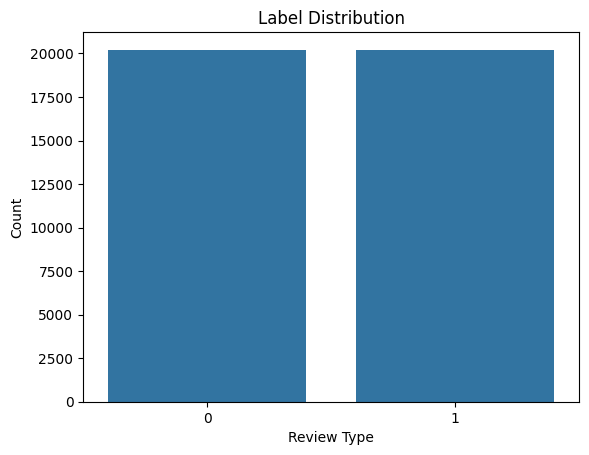

In [69]:
print("\n=== PRODUCT LABEL DISTRIBUTION ===")
plt.Figure(figsize=(6, 4))
sns.countplot(data=product_clean_df, x='label')
plt.title('Label Distribution')
plt.xlabel('Review Type')
plt.ylabel('Count')
plt.show()


=== HOTEL LABEL DISTRIBUTION ===


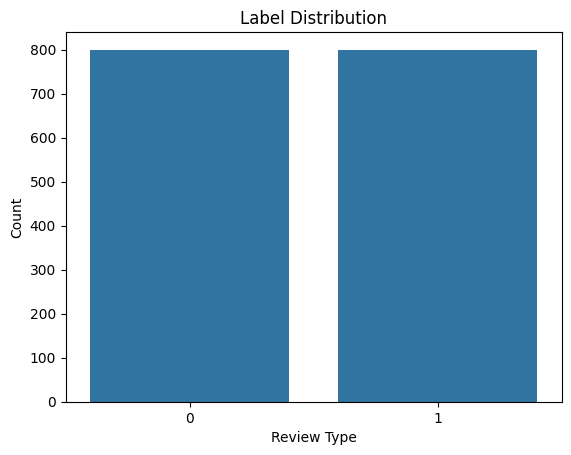

In [70]:
print("\n=== HOTEL LABEL DISTRIBUTION ===")
plt.Figure(figsize=(6, 4))
sns.countplot(data=hotel_clean_df, x='label')
plt.title('Label Distribution')
plt.xlabel('Review Type')
plt.ylabel('Count')
plt.show()

# **3. Text Length Analysis**

The text length analysis shows that **fake product review** are significantly **shorter** than real ones, averaging around 167 characters (27 words) compared to 241 characters (37 words), with a near-zero p-value confirming statistical significance. This indicates that review length could be a useful feature for fake review detection in product data, as shorter and simpler texts are more likely to be fake.

In contrast, **hotel reviews** show minimal length differences between fake and real entries, with a p-value above 0.1. It suggests that length alone is **not a reliable indicator** in this domain. 


=== PRODUCT TEXT LENGTH ANALYSIS ===
FAKE reviews - Avg length: 166.8 chars, 26.8 words
REAL reviews - Avg length: 241.4 chars, 37.3 words
Length difference p-value: 0.000000


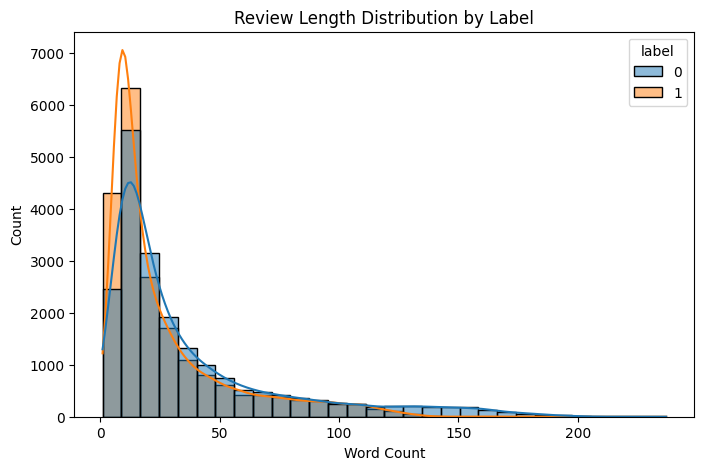


=== HOTEL TEXT LENGTH ANALYSIS ===
FAKE reviews - Avg length: 486.1 chars, 71.6 words
REAL reviews - Avg length: 509.0 chars, 76.3 words
Length difference p-value: 0.110869


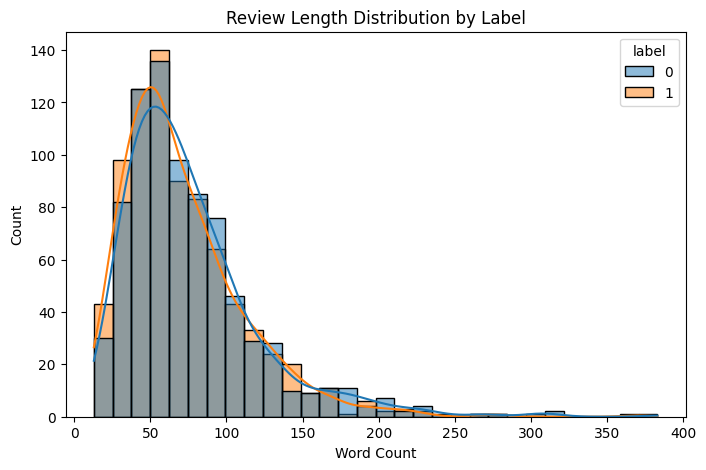

In [71]:
def analyze_text_length(df, dataset_name):
    print(f"\n=== {dataset_name.upper()} TEXT LENGTH ANALYSIS ===")
    
    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    
    # Group by label
    fake_reviews = df[df['label'] == 1]
    real_reviews = df[df['label'] == 0]
    
    print(f"FAKE reviews - Avg length: {fake_reviews['text_length'].mean():.1f} chars, {fake_reviews['word_count'].mean():.1f} words")
    print(f"REAL reviews - Avg length: {real_reviews['text_length'].mean():.1f} chars, {real_reviews['word_count'].mean():.1f} words")
    
    # Statistical significance test
    from scipy.stats import ttest_ind
    t_stat, p_value = ttest_ind(fake_reviews['text_length'], real_reviews['text_length'])
    print(f"Length difference p-value: {p_value:.6f}")

    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='word_count', hue='label', bins=30, kde=True)
    plt.title('Review Length Distribution by Label')
    plt.xlabel('Word Count')
    plt.show()
    
    return df

product_clean_df = analyze_text_length(product_clean_df, "PRODUCT")
hotel_clean_df = analyze_text_length(hotel_clean_df, "HOTEL")

## **4. Linguistic Feature Analysis (Using Raw Text Data)**

The linguistic analysis highlights distinct stylistic differences between fake and real reviews, particularly in punctuation and numeric usage.

- **Product reviews**： Real entries contain more exclamations (0.52 vs. 0.28), questions (0.1 vs 0.01), and digits(1.5 vs. 0.75), suggesting that real users are more expressive and detailed. 

- **Hotel reviews**：It shows a similar trend, with real reviews including more questions (0.19 vs 0.08) and notably higher digit usage (3.63 vs 1.2). Uppercase ratios remain comparable across classes, indicating that capitalization is not a strong differentiator.

Overall, **fake reviews** tend to be **less expressive** and contain **fewer numeric details**, making these linguistic features valuable. 

In [72]:
def linguistic_analysis(df, dataset_name):
    print(f"\n=== {dataset_name.upper()} LINGUISTIC ANALYSIS ===")
    
    # Calculate linguistic features
    df['exclamation_count'] = df['text'].str.count('!')
    df['question_count'] = df['text'].str.count(r'\?')
    df['uppercase_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if x else 0)
    df['digit_count'] = df['text'].str.count(r'\d')
    
    # Compare fake vs real
    fake_reviews = df[df['label'] == 1]
    real_reviews = df[df['label'] == 0]
    
    features = ['exclamation_count', 'question_count', 'uppercase_ratio', 'digit_count']
    
    for feature in features:
        fake_mean = fake_reviews[feature].mean()
        real_mean = real_reviews[feature].mean()
        print(f"{feature}: FAKE={fake_mean:.3f}, REAL={real_mean:.3f}")
    
    return df

product_raw_df = linguistic_analysis(product_raw_df, "PRODUCT")
hotel_raw_df = linguistic_analysis(hotel_raw_df, "HOTEL")



=== PRODUCT LINGUISTIC ANALYSIS ===
exclamation_count: FAKE=0.276, REAL=0.519
question_count: FAKE=0.011, REAL=0.095
uppercase_ratio: FAKE=0.031, REAL=0.030
digit_count: FAKE=0.753, REAL=1.496

=== HOTEL LINGUISTIC ANALYSIS ===
exclamation_count: FAKE=0.978, REAL=0.996
question_count: FAKE=0.077, REAL=0.194
uppercase_ratio: FAKE=0.025, REAL=0.024
digit_count: FAKE=1.198, REAL=3.634


## **5. Most Common Words Analysis**

Word frequency analysis reveals that **fake and real** reviews **share similar positive sentiment vocabulary** ("great," "good," "love") but differ in contextual usage. 

- **Product Reviews:** Fake reviews rely heavily on generic praise and narrative terms like "story" and "read," while authentic reviews include more experiential language such as "one" and "time."

- **Hotel Review:** Authentic reviews reference specific service elements ("room," "stay," "staff," "night"), whereas fake reviews repetitively use location names ("Chicago") and generic hotel terminology without providing substantive experiential details.

The analysis demonstrates that deceptive reviews exhibit repetitive, generic praise patterns while authentic reviews employ more diverse, experience-based vocabulary.

In [73]:
def word_frequency_analysis(df, dataset_name):
    print(f"\n=== {dataset_name.upper()} WORD FREQUENCY ANALYSIS ===")
    
    stop_words = set(stopwords.words('english'))
    
    # Separate fake and real reviews
    fake_texts = ' '.join(df[df['label'] == 1]['text'].tolist())
    real_texts = ' '.join(df[df['label'] == 0]['text'].tolist())
    
    # Get word frequencies (excluding stop words)
    fake_words = [word for word in fake_texts.split() if word.lower() not in stop_words and len(word) > 2]
    real_words = [word for word in real_texts.split() if word.lower() not in stop_words and len(word) > 2]
    
    fake_freq = Counter(fake_words).most_common(10)
    real_freq = Counter(real_words).most_common(10)
    
    print("Top 10 Truthful Words:", real_freq[:10])
    print("Top 10 Deceptive Words:", fake_freq[:10])

word_frequency_analysis(product_clean_df, "PRODUCT")
word_frequency_analysis(hotel_clean_df, "HOTEL")


=== PRODUCT WORD FREQUENCY ANALYSIS ===
Top 10 Truthful Words: [('one', 7315), ('book', 6353), ('great', 5784), ('like', 5495), ('love', 4928), ('good', 4773), ('would', 4325), ('well', 4225), ('get', 4094), ('time', 3735)]
Top 10 Deceptive Words: [('book', 10938), ('great', 10645), ('love', 10502), ('good', 9455), ('one', 7238), ('story', 6973), ('well', 6063), ('would', 6037), ('read', 5618), ('little', 5319)]

=== HOTEL WORD FREQUENCY ANALYSIS ===
Top 10 Truthful Words: [('room', 1715), ('hotel', 1646), ('stay', 610), ('great', 541), ('chicago', 485), ('would', 443), ('staff', 438), ('night', 434), ('service', 394), ('bed', 372)]
Top 10 Deceptive Words: [('hotel', 1982), ('room', 1736), ('chicago', 1034), ('stay', 708), ('would', 473), ('service', 461), ('staff', 400), ('one', 360), ('time', 342), ('like', 329)]


## **6. Sentiment And Emotional Analysis**

**Product Reviews - "Artificial Positivity" Pattern:**

- Fake reviews are overly positive: 1.18 vs 0.90 positive words (+31% more positive language)
- Fake reviews avoid criticism: 0.03 vs 0.08 negative words (62% less negative language)
- This suggests fake product reviewers use artificial enthusiasm and avoid any negative comments to appear credible

**Hotel Reviews - "Balanced Authenticity" Pattern (Opposite Behavior):**

- Fake reviews are less positive: 1.04 vs 1.28 positive words (19% less positive language)
- Fake reviews use more criticism: 0.25 vs 0.20 negative words (25% more negative language)
- This suggests fake hotel reviewers try to appear more balanced and critical to seem authentic

In [74]:
def sentiment_analysis(df, dataset_name):
    print(f"\n=== {dataset_name.upper()} SENTIMENT ANALYSIS ===")
    
    # Simple sentiment indicators
    positive_words = ['good', 'great', 'excellent', 'amazing', 'love', 'perfect', 'best', 'wonderful']
    negative_words = ['bad', 'terrible', 'awful', 'hate', 'worst', 'horrible', 'disappointing']
    
    df['positive_word_count'] = df['text'].apply(lambda x: sum(1 for word in positive_words if word in x.lower()))
    df['negative_word_count'] = df['text'].apply(lambda x: sum(1 for word in negative_words if word in x.lower()))
    df['sentiment_ratio'] = df['positive_word_count'] / (df['negative_word_count'] + 1)  # +1 to avoid division by zero
    
    # Compare fake vs real
    fake_reviews = df[df['label'] == 1]
    real_reviews = df[df['label'] == 0]
    
    print(f"FAKE reviews - Avg positive words: {fake_reviews['positive_word_count'].mean():.2f}")
    print(f"REAL reviews - Avg positive words: {real_reviews['positive_word_count'].mean():.2f}")
    print(f"FAKE reviews - Avg negative words: {fake_reviews['negative_word_count'].mean():.2f}")
    print(f"REAL reviews - Avg negative words: {real_reviews['negative_word_count'].mean():.2f}")
    
    return df

product_clean_df = sentiment_analysis(product_clean_df, "PRODUCT")
hotel_clean_df = sentiment_analysis(hotel_clean_df, "HOTEL")


=== PRODUCT SENTIMENT ANALYSIS ===
FAKE reviews - Avg positive words: 1.18
REAL reviews - Avg positive words: 0.90
FAKE reviews - Avg negative words: 0.03
REAL reviews - Avg negative words: 0.08

=== HOTEL SENTIMENT ANALYSIS ===
FAKE reviews - Avg positive words: 1.04
REAL reviews - Avg positive words: 1.28
FAKE reviews - Avg negative words: 0.25
REAL reviews - Avg negative words: 0.20


## **7. Key Insights Summary**

#### **Critical Finding: Domain-Specific Deception Strategies**

Our analysis reveals that fake review detection cannot rely on universal patterns - instead, fraudsters adapt their strategies based on the domain, making transfer learning both challenging and essential.

#### **Product Reviews: Clear Discriminative Signals**

**Text Length:** Fake reviews are **39% shorter** (26.8 vs 37.3 words, p<0.000001) - the strongest single discriminator

**Linguistic Patterns:** Fake reviews are less expressive, using fewer exclamations, questions, and numeric details, while real reviews include more punctuation and digits, reflecting richer and more verifiable experiences. Uppercase usage is similar, making it a weak differentiator.

**Emotional Over-Compensation:** Fake reviews use 84% more "great", 113% more "love", and 98% more "good" while avoiding criticism entirely

#### **Hotel Reviews: Sophisticated Deception**

**Text Length:** No significant difference (71.6 vs 76.3 words, p=0.11) - fake reviewers are more **sophisticated**

**Linguistic Patterns:** Minimal differences across all features except digit usage (67% fewer specifics)

**Balanced Authenticity Strategy:** Opposite of products - fake hotel reviews use 19% fewer positive words and 25% more negative words to appear balanced and authentic

**Geographic Name-Dropping:** 113% more location mentions ("chicago") to establish credibility